In [71]:
# import vari
import numpy as np
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sb

In [72]:
samplesize = 0.05
sample = pd.read_pickle(f"./data/sample_{samplesize}_clean.pkl")
dataset = sample

<Axes: ylabel='Frequency'>

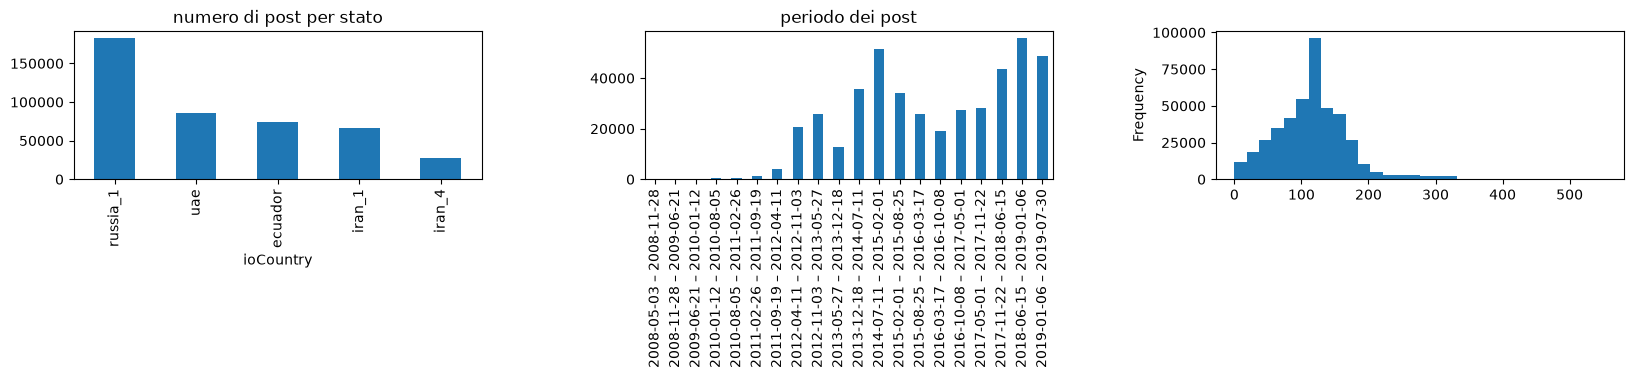

In [ ]:
import matplotlib.pyplot as plt
# Set up a grid of plots:
fig = plt.figure(figsize=(20, 10)) 
fig_dims = (4, 3)
fig.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot2grid(fig_dims, (0, 0))
dataset["ioCountry"].value_counts().plot(kind='bar',title='numero di post per stato')

plt.subplot2grid(fig_dims, (0, 1))
# quando si tratta di punti nel tempo, usare sturges o simili per calcolare il numero di bucket
# sarebbe sbagliato, perché non seguono una distribuzione normale (potrebbero farlo come ora del giorno)
# è più ragionevole usare un numero fisso i buckets che non sia troppo alto da risultare scomodo
# pandas si incasina con le date, quindi prima assegnamo a ogni record il suo bucket
ptc = dataset["post_time_clean"]
buckets = pd.cut(ptc, bins=20).value_counts(sort=False)
# poi sistemiamo l'etichetta da precisione piena a giusto il giorno
buckets.index = [f"{b.left:%Y-%m-%d} – {b.right:%Y-%m-%d}" for b in buckets.index]
# e poi plottiamo
buckets.plot(kind="bar", title="periodo dei post")
# dataset["post_time_clean"].plot(kind="hist", title="periodo dei post", bins=20)

plt.subplot2grid(fig_dims, (0, 2))
# usare la lunghezza del testo è un po' grezzo, così come il numero di parole (possono cambiare col linguaggio),
# ma per farsi un'idea iniziale funziona. Anche in questo caso sturges è un po' grezzo, e usiamo un numero comodo di bins

dataset["post_text_clean"].str.len().plot(kind="hist", bins=30) 
# anche in questo caso ci sono evidentemente degli outlier molto lunghi e poco comuni
